In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from blackjax.util import run_inference_algorithm
from sklearn.preprocessing import StandardScaler

from non_parametric_pro import ula
from non_parametric_pro.density import ProParameters, pro_logdensity_fn, pro_score_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, train_val_split
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation
from non_parametric_pro.inducing import PointInducingBasis, compute_inducing_basis, kmeans_inducing_points
from non_parametric_pro.gp import _full_gp_basis, predictive_log_likelihood

jax.config.update("jax_enable_x64", True)

In [59]:
dataset_name = "airfoil"
split = 1

num_inducing_points = 200
val_fraction = 0.2

In [60]:
key = jr.PRNGKey(0)

example = load_uci_regression_dataset(dataset_name, split=split)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_full = jnp.array(scaler_x.fit_transform(example.x_train))
y_full = jnp.array(scaler_y.fit_transform(example.y_train))

data_split = train_val_split(key, x_full, y_full, val_fraction=val_fraction)
x_train, y_train, x_val, y_val = jnp.array(data_split.x_train), jnp.array(data_split.y_train), jnp.array(data_split.x_val), jnp.array(data_split.y_val)

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [61]:
M = num_inducing_points
D = x_full.shape[1]
N = x_full.shape[0]

data = gpx.Dataset(X=x_full, y=y_full)
kernel = gpx.kernels.Matern32(lengthscale=jnp.ones((D,)), variance=px.NonTrainable(jnp.array(1.0)))
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood
optim = ox.adam(learning_rate=0.01)

z_init = kmeans_inducing_points(key, x_full, M).z 

variational_family = gpx.variational_families.VariationalGaussian(
    posterior=posterior,
    inducing_inputs=z_init,
)

opt_variational_family, _ = gpx.fit(
    model=variational_family,
    objective=lambda p, d: -gpx.objectives.elbo(p, d),
    train_data=data,
    optim=optim,
    num_iters=500,
    batch_size=128,
    verbose=False,
)

v_gp_posterior = opt_variational_family.posterior

v_gp_latent_dist = opt_variational_family.predict(x_test)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

v_gp_sigma = v_gp_posterior.likelihood.obs_stddev
v_gp_kernel = v_gp_posterior.prior.kernel

z_opt = px.unwrap(opt_variational_family.inducing_inputs)

print("VGP NLPD:", nlpd_gp(y_test, v_gp_predictive_mean, v_gp_predictive_std))

VGP NLPD: 0.38969115367693025


In [62]:
# M = 100

# from non_parametric_pro.inducing import RFFInducingBasis, sample_rff_frequencies

# freqs = sample_rff_frequencies(key, v_gp_kernel, num_basis_fns=M)
# rff_basis = RFFInducingBasis(frequencies=freqs)
# basis, residual_std = compute_inducing_basis(rff_basis, kernel, x_train)

# inducing_basis = RFFInducingBasis(frequencies=freqs)

In [63]:
from non_parametric_pro.density import ProParameters, pro_logdensity_fn
import blackjax

In [64]:
x = x_full
y = y_full

inducing_basis = PointInducingBasis(z=z_opt)
basis, residual_std = compute_inducing_basis(inducing_basis, v_gp_kernel, x)

J = 10

pro_kernel = v_gp_kernel

_sigma_val = 0.1
_sigma_min = 0.01

sigma = gpx.parameters.SigmoidBounded(_sigma_val, low=_sigma_min, high=100.0)

pro_params = ProParameters(
    y=y,
    basis=basis,
    step_size=1e-4,
    sigma=sigma,
    alpha=1,
    residual_std=residual_std,
)

mala = blackjax.mala(lambda z: pro_logdensity_fn(z, pro_params), 0.001)
num_steps = 15000

initial_position = jr.normal(key, (M, J))

algorithm = parametric_ula(pro_logdensity_fn, pro_params)

out, info = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=num_steps,
    initial_position=initial_position,
    progress_bar=True
)

<div><progress max="15000" value="15000"></progress> 100.00% [15000/15000 00:00&lt;?]</div>

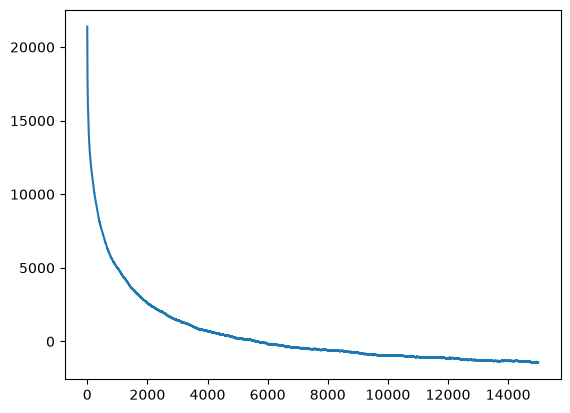

In [65]:
plt.plot(-info[1].score)
plt.show()

In [66]:
burn = int(num_steps * 0.8)
thin = 50

x = x_test
y = y_test
x_basis = x_full

particles = info[0].position[burn::thin]
test_basis, test_cov = prediction_basis(pro_kernel, x_basis, x, pro_params, inducing_basis=inducing_basis)

v_gp_latent_dist = v_gp_posterior.predict(x, train_data=data)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

print("PRO NLPD:", nlpd_pro(y, test_basis, test_cov, particles, parameters=pro_params))
print("VGP NLPD:", nlpd_gp(y, v_gp_predictive_mean, v_gp_predictive_std))

PRO NLPD: 0.21950244602399382
VGP NLPD: 0.288963740683263


0.7592591686680022


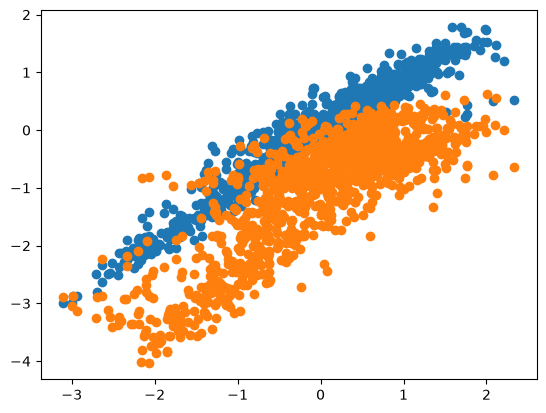

In [11]:
v_gp_latent_dist = v_gp_posterior.predict(x_train, train_data=data)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

burn = int(num_steps * 0.8)
thin = 50

particles = info[0].position[burn::thin]

test_basis, test_cov = prediction_basis(
    pro_kernel,
    x_train,
    x_train,
    pro_params,
    inducing_basis=inducing_basis,
)

particle_matrix = particles
if particles.ndim == 3:
    particle_matrix = jnp.transpose(particles, (1, 0, 2)).reshape(particles.shape[1], -1)

projected = test_basis @ particle_matrix      # (N_test, J_total)
mean = jnp.mean(projected, axis=1) 

plt.scatter(y_train, v_gp_predictive_mean)
plt.scatter(y_train, mean)
plt.show()

PRO NLPD: 5.431467391741333
VGP NLPD: 0.24183840001362542


In [ ]:
# x = x_train
# y = y_train
# _x_val = x_val
# _y_val = y_val

# inducing_basis = PointInducingBasis(z=z_opt)
# basis, residual_std = compute_inducing_basis(inducing_basis, kernel, x)

# num_particles = 1
# J = num_particles

# pro_kernel = v_gp_kernel

# _sigma_val = px.unwrap(v_gp_sigma)
# _sigma_min = 0.01

# sigma = gpx.parameters.SigmoidBounded(_sigma_val, low=_sigma_min, high=100.0)

# pro_params = ProParameters(
#     y=y,
#     basis=basis,
#     step_size=1e-4,
#     sigma=sigma,
#     alpha=1,
#     residual_std=residual_std
# )

# num_steps = 10000
# warmup_steps = 1000
# sigma_adapt_every = 10
# kernel_adapt_every = -1
# initial_position = jr.normal(key, (M, J))

# adaptation = parameter_adaptation(
#     ula,
#     pro_logdensity_fn,
#     pro_params,
#     x_train=x,
#     initial_kernel=pro_kernel,
#     warmup_steps=warmup_steps,
#     sigma_adapt_every=sigma_adapt_every,
#     kernel_adapt_every=kernel_adapt_every,
#     objective_fn=pro_logdensity_fn,
#     inducing_basis=inducing_basis,
#     sigma_optimizer=ox.adam(1e-1),
#     kernel_optimizer=ox.adam(1e-1),
#     x_val=_x_val,
#     y_val=_y_val,
#     progress_bar=True
# )

# adaptation_results, adaptation_info = adaptation.run(key, initial_position, num_steps=num_steps)
# pro_kernel = jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
# pro_params = adaptation_results.parameters
# pro_position = adaptation_results.state.position

# fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

# ax[0].plot(px.unwrap(adaptation_info.sigma))
# ax[1].plot(px.unwrap(adaptation_info.kernel.lengthscale))
# ax[2].plot(px.unwrap(adaptation_info.kernel.variance))
# ax[3].plot(-adaptation_info.sampler_info.score[10:])
# plt.tight_layout()
# plt.show()

In [105]:
# num_steps = 5000
# pro_params = pro_params._replace(step_size=1e-4)
# algorithm = parametric_ula(pro_logdensity_fn, pro_params)

# out, info = run_inference_algorithm(
#     rng_key=key,
#     inference_algorithm=algorithm,
#     num_steps=num_steps,
#     initial_position=pro_position,
#     progress_bar=True
# )

# plt.plot(-info[1].score)
# plt.show()